# Pipelines ETL simples

**Seminario de Actualización — Unidad 5**
Práctica principal: construcción de un pipeline ETL con Python y SQL Server

## Objetivos de la clase

1. Distinguir ETL de ELT y saber cuándo conviene cada uno.
2. Extraer datos de tres orígenes distintos: SQL Server, un archivo plano y una API.
3. Transformar y combinar esos orígenes con operaciones vectorizadas.
4. Cargar el resultado de forma **idempotente**.
5. Estructurar el pipeline en funciones con responsabilidad única, con manejo de errores y *logging*.

## ETL frente a ELT

| | **ETL** | **ELT** |
|---|---|---|
| Dónde se transforma | En un proceso intermedio (script de Python) | Dentro del motor de destino, después de cargar |
| Cuándo conviene | Volúmenes moderados, transformaciones complejas | Grandes volúmenes y un motor de destino potente |
| Qué llega al destino | Solo el dato ya transformado | El dato crudo, y luego el transformado |

In [1]:
import logging
from pathlib import Path

import pandas as pd

import config_conexion
import datos_demo

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
log = logging.getLogger("pipeline_ventas")

disponible = config_conexion.probar_conexion()
engine = config_conexion.crear_engine() if disponible else None

CARPETA = Path("datos")
datos_demo.escribir_csv(CARPETA)
log.info("Archivos de origen preparados en %s", CARPETA.resolve())

No se pudo conectar a SQL Server: OperationalError: (pyodbc.OperationalError) ('08001', '[08001] [Microsoft][ODBC Driver 18 for SQL Server]Named Pipes Provider: Could not open a connection to SQL Server [2].  (2) (SQLDriverConnect); [08001] [Microsoft][ODBC Driver 18 for SQL Server]Login timeout expired (0); [08001] [Microsoft][ODBC Driver 18 for SQL Server]A network-related or instance-specific error has occurred while establishing a connection to localhost. Server is not found or not accessible. Check if instance name is correct and if SQL Server is configured to allow remote connections. For more information see SQL Server Books Online. (2)')
(Background on this error at: https://sqlalche.me/e/21/e3q8)


21:46:43  INFO     Archivos de origen preparados en C:\Users\joi\git\lujan\2026\datos


## 1. Extract: obtener los datos

Los orígenes más frecuentes son tres: una consulta contra SQL Server, un archivo plano
(CSV o Excel) y una API REST. Los tres terminan en un `DataFrame`.

Acá se combinan los dos primeros: la vista `ValoresPedido` de Pampero, y una planilla de
**metas mensuales por empleado** que el área comercial mantiene por fuera de la base.

Nótese el `encoding="utf-8"` explícito al leer el CSV: la codificación es una de las causas
más frecuentes de fallo silencioso en archivos con acentos.

In [2]:
CONSULTA = """
    SELECT v.IDPedido, v.IDCliente, v.IDEmpleado, v.EnvioPor,
           v.FechaPedido, v.FechaRequerida, v.FechaEnvio,
           v.cantidad, v.val,
           c.NombreEmpresa, c.Ciudad, c.Region, c.Pais
    FROM ValoresPedido AS v
      JOIN Clientes AS c
        ON c.IDCliente = v.IDCliente
"""

def extraer_pedidos() -> pd.DataFrame:
    """Origen 1: la vista ValoresPedido unida a Clientes, desde SQL Server."""
    if disponible:
        log.info("Extrayendo pedidos desde SQL Server")
        return pd.read_sql(CONSULTA, engine)
    log.warning("SQL Server no disponible: se leen los pedidos desde el CSV de respaldo")
    pedidos = pd.read_csv(CARPETA / "valores_pedido.csv", encoding="utf-8")
    clientes = pd.read_csv(CARPETA / "clientes.csv", encoding="utf-8")
    return pedidos.merge(
        clientes[["IDCliente", "NombreEmpresa", "Ciudad", "Region", "Pais"]],
        on="IDCliente", how="inner")


def extraer_metas() -> pd.DataFrame:
    """Origen 2: las metas mensuales de venta por empleado.

    Es información que vive fuera de la base transaccional, en una planilla del
    área comercial. Se combina por IDEmpleado, Anio y Mes.
    """
    ruta = CARPETA / "metas_empleado.csv"
    log.info("Extrayendo metas comerciales desde %s", ruta)
    return pd.read_csv(ruta, encoding="utf-8")


pedidos = extraer_pedidos()
metas = extraer_metas()

print(f"pedidos : {pedidos.shape[0]:>6} filas x {pedidos.shape[1]} columnas")
print(f"metas   : {metas.shape[0]:>6} filas x {metas.shape[1]} columnas")

21:46:43  WARNING  SQL Server no disponible: se leen los pedidos desde el CSV de respaldo
21:46:43  INFO     Extrayendo metas comerciales desde datos\metas_empleado.csv


pedidos :    870 filas x 13 columnas
metas   :    207 filas x 4 columnas


In [3]:
# Origen 3: una API REST. Se deja envuelto en try/except porque el laboratorio
# puede no tener salida a internet: el pipeline debe seguir funcionando sin este origen.
def extraer_tipo_cambio() -> pd.DataFrame | None:
    import requests

    try:
        respuesta = requests.get("https://api.frankfurter.dev/v2/rate/usd/ars", timeout=10)
        respuesta.raise_for_status()
        return pd.json_normalize(respuesta.json())
    except requests.RequestException as error:
        log.warning("No se pudo consultar la API de tipo de cambio: %s", error)
        return None


tipo_cambio = extraer_tipo_cambio()
print(tipo_cambio if tipo_cambio is not None else "Sin datos de tipo de cambio.")

         date base quote     rate
0  2026-10-08  USD   ARS  1518.46


## 2. Transform: limpiar y combinar

La etapa que consume la mayor parte del tiempo en un pipeline real. Las tareas habituales
son las mismas que se diagnosticaron en la clase 22: tipos, faltantes, duplicados,
normalización de texto, y la combinación de orígenes por clave.

`merge` replica la semántica de los `JOIN` de la Unidad 3: `how` admite `inner`, `left`,
`right` y `outer`, con el mismo significado que `INNER`, `LEFT OUTER`, `RIGHT OUTER` y
`FULL OUTER JOIN`.

In [4]:
def transformar(pedidos: pd.DataFrame, metas: pd.DataFrame) -> pd.DataFrame:
    """Limpia, agrega por empleado y mes, y combina con las metas comerciales."""
    log.info("Transformando %d filas de pedidos", len(pedidos))

    # Tipos
    pedidos["FechaPedido"] = pd.to_datetime(pedidos["FechaPedido"], errors="coerce")
    pedidos["FechaEnvio"] = pd.to_datetime(pedidos["FechaEnvio"], errors="coerce")
    pedidos["val"] = pd.to_numeric(pedidos["val"], errors="coerce")

    # Duplicados por extracción repetida
    antes = len(pedidos)
    pedidos = pedidos.drop_duplicates(subset=["IDPedido"], keep="first")
    log.info("Duplicados eliminados: %d", antes - len(pedidos))

    # Faltantes que invalidan la fila
    pedidos = pedidos.dropna(subset=["IDCliente", "val", "FechaPedido"])

    # Normalización de texto
    pedidos["Pais"] = (pedidos["Pais"].str.strip().str.upper()
                       .replace({"EEUU": "EE.UU.", "ESTADOS UNIDOS": "EE.UU.",
                                 "REINO  UNIDO": "REINO UNIDO"}))

    # Reglas de negocio
    antes = len(pedidos)
    pedidos = pedidos[(pedidos["val"] > 0) &
                      (pedidos["FechaPedido"] <= pd.Timestamp.today())]
    log.info("Filas descartadas por reglas de negocio: %d", antes - len(pedidos))

    # Agregación mensual por empleado, que es el grano de las metas.
    pedidos["Anio"] = pedidos["FechaPedido"].dt.year
    pedidos["Mes"] = pedidos["FechaPedido"].dt.month
    mensual = (pedidos.groupby(["IDEmpleado", "Anio", "Mes"], as_index=False)
                      .agg(Pedidos=("IDPedido", "count"),
                           Unidades=("cantidad", "sum"),
                           Ventas=("val", "sum")))
    mensual["Ventas"] = mensual["Ventas"].round(2)

    # Combinación con el segundo origen: equivale a un LEFT OUTER JOIN.
    resultado = mensual.merge(metas, on=["IDEmpleado", "Anio", "Mes"], how="left")

    sin_meta = int(resultado["MetaMensual"].isna().sum())
    if sin_meta:
        log.warning("%d meses sin meta cargada", sin_meta)

    # Columnas derivadas, vectorizadas.
    resultado["CumplimientoMeta"] = (
        resultado["Ventas"] / resultado["MetaMensual"]).round(3)
    resultado["TicketPromedio"] = (
        resultado["Ventas"] / resultado["Pedidos"]).round(2)

    log.info("Transformación finalizada: %d filas resultantes", len(resultado))
    return resultado


enriquecidas = transformar(pedidos, metas)
enriquecidas.head()

21:46:44  INFO     Transformando 870 filas de pedidos
21:46:44  INFO     Duplicados eliminados: 40
21:46:44  INFO     Filas descartadas por reglas de negocio: 0
21:46:44  INFO     Transformación finalizada: 201 filas resultantes


,IDEmpleado,Anio,Mes,Pedidos,Unidades,Ventas,MetaMensual,CumplimientoMeta,TicketPromedio
0,1,2019,7,5,388,10512.10,34870.22,0.301,2102.42
1,1,2019,8,5,231,6883.32,39837.74,0.173,1376.66
2,1,2019,9,3,114,2670.82,29578.99,0.090,890.27
3,1,2019,10,6,299,5158.74,59584.86,0.087,859.79
4,1,2019,11,2,190,2541.93,14612.61,0.174,1270.96


## 3. Load: cargar el resultado

La decisión de diseño central de esta etapa es la **idempotencia**: si el pipeline corre más
de una vez (porque está programado, o porque falló y se reintenta), ¿el resultado final es el
mismo o los datos se duplican?

| Estrategia | Cómo | Cuándo |
|---|---|---|
| **Reemplazo completo** | `if_exists="replace"`, o `TRUNCATE` + `append` | Volúmenes moderados. Simple y seguro |
| **Carga incremental** | Insertar solo lo nuevo, actualizar lo modificado (*upsert*) | Grandes volúmenes. Más eficiente, más compleja |

Para pipelines simples como este, el reemplazo completo es la opción razonable.

In [5]:
TABLA_DESTINO = "CumplimientoMensualU05"


def cargar(datos: pd.DataFrame) -> None:
    """Carga idempotente: reemplazo completo de la tabla destino."""
    log.info("Cargando %d filas en %s", len(datos), TABLA_DESTINO)
    if disponible:
        datos.to_sql(TABLA_DESTINO, engine, if_exists="replace",
                     index=False, chunksize=1000)
    else:
        salida = CARPETA / f"{TABLA_DESTINO}.csv"
        datos.to_csv(salida, index=False, encoding="utf-8")
        log.warning("Sin servidor: el resultado se escribió en %s", salida)


cargar(enriquecidas)

21:46:44  INFO     Cargando 201 filas en CumplimientoMensualU05
21:46:44  WARNING  Sin servidor: el resultado se escribió en datos\CumplimientoMensualU05.csv


## 4. El pipeline completo

Cada función tiene una responsabilidad única, lo que permite probarla de forma aislada. La
función de orquestación las llama en orden y registra lo que ocurre.

Sobre el `try/except`: **no oculta el error**. Lo registra con `log.exception`, que incluye la
traza completa, y lo vuelve a lanzar con `raise`, de modo que el proceso que invocó al
pipeline (el Programador de tareas de Windows, `cron`, el Agente SQL Server) reciba un
código de salida distinto de cero y la falla no pase inadvertida.

In [6]:
def ejecutar_pipeline() -> pd.DataFrame:
    """Orquesta las tres etapas y garantiza que un fallo sea visible."""
    try:
        log.info("=== Inicio del pipeline ===")
        pedidos = extraer_pedidos()
        metas = extraer_metas()
        resultado = transformar(pedidos, metas)
        cargar(resultado)
        log.info("=== Pipeline finalizado correctamente ===")
        return resultado
    except Exception:
        log.exception("El pipeline falló")
        raise


resultado = ejecutar_pipeline()
print(f"\nFilas procesadas: {len(resultado)}")

21:46:44  INFO     === Inicio del pipeline ===
21:46:44  WARNING  SQL Server no disponible: se leen los pedidos desde el CSV de respaldo
21:46:44  INFO     Extrayendo metas comerciales desde datos\metas_empleado.csv
21:46:44  INFO     Transformando 870 filas de pedidos
21:46:44  INFO     Duplicados eliminados: 40
21:46:44  INFO     Filas descartadas por reglas de negocio: 0
21:46:44  INFO     Transformación finalizada: 201 filas resultantes
21:46:44  INFO     Cargando 201 filas en CumplimientoMensualU05
21:46:44  WARNING  Sin servidor: el resultado se escribió en datos\CumplimientoMensualU05.csv
21:46:44  INFO     === Pipeline finalizado correctamente ===



Filas procesadas: 201


## 5. Verificación de idempotencia

La prueba es directa: ejecutar el pipeline dos veces seguidas y comprobar que el resultado
final es idéntico. Si al segundo intento la tabla destino tiene el doble de filas, el
pipeline **no** es idempotente y no puede programarse sin riesgo.

In [7]:
primera = ejecutar_pipeline()
segunda = ejecutar_pipeline()

print()
print(f"Filas tras la primera corrida : {len(primera)}")
print(f"Filas tras la segunda corrida : {len(segunda)}")
print(f"¿Resultado idéntico? {len(primera) == len(segunda)}")

if disponible:
    conteo = pd.read_sql(f"SELECT COUNT(*) AS Filas FROM {TABLA_DESTINO}", engine)
    print(f"Filas en la tabla destino     : {conteo['Filas'].iloc[0]}")

21:46:44  INFO     === Inicio del pipeline ===
21:46:44  WARNING  SQL Server no disponible: se leen los pedidos desde el CSV de respaldo
21:46:44  INFO     Extrayendo metas comerciales desde datos\metas_empleado.csv
21:46:44  INFO     Transformando 870 filas de pedidos
21:46:44  INFO     Duplicados eliminados: 40
21:46:44  INFO     Filas descartadas por reglas de negocio: 0
21:46:44  INFO     Transformación finalizada: 201 filas resultantes
21:46:44  INFO     Cargando 201 filas en CumplimientoMensualU05
21:46:44  WARNING  Sin servidor: el resultado se escribió en datos\CumplimientoMensualU05.csv
21:46:44  INFO     === Pipeline finalizado correctamente ===
21:46:44  INFO     === Inicio del pipeline ===
21:46:44  WARNING  SQL Server no disponible: se leen los pedidos desde el CSV de respaldo
21:46:44  INFO     Extrayendo metas comerciales desde datos\metas_empleado.csv
21:46:44  INFO     Transformando 870 filas de pedidos
21:46:44  INFO     Duplicados eliminados: 40
21:46:44  INFO     Fi


Filas tras la primera corrida : 201
Filas tras la segunda corrida : 201
¿Resultado idéntico? True


In [8]:
# Un resumen agregado del resultado, para verificar que el contenido tiene sentido
resultado.groupby("IDEmpleado").agg(
    Meses=("Mes", "count"),
    Ventas=("Ventas", "sum"),
    CumplimientoMedio=("CumplimientoMeta", "mean"),
).round(2).sort_values("Ventas", ascending=False)

,Meses,Ventas,CumplimientoMedio
IDEmpleado,,,
7,22,182368.97,0.46
9,23,181634.43,0.33
2,22,164907.40,0.25
1,21,163376.66,0.28
4,23,161883.43,0.29
8,22,153463.65,0.20
3,23,146724.70,0.16
5,23,144805.18,0.21
6,22,131964.41,0.24


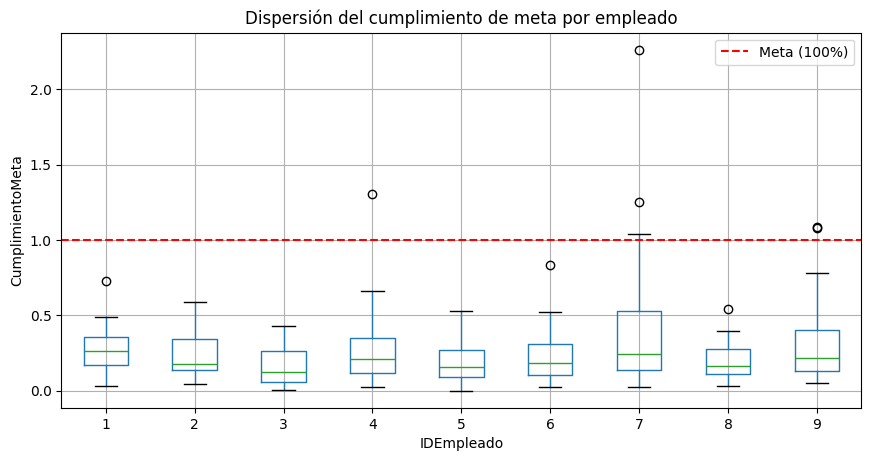

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
resultado.boxplot(column="CumplimientoMeta", by="IDEmpleado", ax=ax)
ax.axhline(1, color="red", linestyle="--", label="Meta (100%)")
ax.set_title("Dispersión del cumplimiento de meta por empleado")
fig.suptitle("")
ax.set_xlabel("IDEmpleado")
ax.set_ylabel("CumplimientoMeta")
ax.legend()
plt.show()

## 6. Más allá de lo simple: orquestación

Un script como este puede programarse con herramientas del sistema operativo (el Programador
de tareas de Windows, `cron` en Linux) o con el **Agente SQL Server**, que permite invocar un
script externo como parte de un *job*.

Cuando la cantidad de pipelines crece y aparecen dependencias entre ellos (este proceso debe
correr después de aquel, y reintentarse si falla), se pasa a un orquestador: **Apache Airflow**,
**Azure Data Factory**, **Dagster**. El bloque constructivo sigue siendo el mismo
—extraer, transformar, cargar— pero a otra escala.

El archivo `pipeline_ventas.py`, en esta misma carpeta, contiene la versión de este pipeline
lista para ejecutarse desde la línea de comandos, que es lo que un programador de tareas necesita.